In [ ]:
import os
import sys
import time
import joblib
from pathlib import Path

sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler
from torch.utils.data import DataLoader, random_split, TensorDataset

from utils.models import CNNLSTM
from utils.preprocessing import (
    balance_dataset,
    load_cicids2017_data,
    load_ciciot2023_data,
)
from utils.evaluation import evaluate_model
from properties import build_properties

In [2]:
# =========================
# Config: Define datasets
# =========================
df_cicids2017 = load_cicids2017_data()
df_ciciot2023 = load_ciciot2023_data()

DATASETS = {
    "cicids2017": {"data": df_cicids2017},
    "ciciot2023": {"data": df_ciciot2023},
}

TARGET_LABELS = ["BENIGN", "DOS_HTTP_FLOOD", "PORTSCAN"]

BATCH_SIZE = 256
NUM_EPOCHS = 10
LEARNING_RATE = 1e-3
TEST_SIZE = 0.3
LAMBDA_PROP = 0.1
WINDOW_SECONDS = 5.0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [ ]:
def add_portscan_attack_features(df: pd.DataFrame, window_seconds: float = 5.0) -> pd.DataFrame:
    df = df.copy()

    # label cleanup
    df["label"] = df["label"].astype(str).str.strip().str.upper()
    df = df[df["label"].isin(TARGET_LABELS)].copy()

    # PORTSCAN features
    df["window_id"] = (df["ts"] // window_seconds).astype(int)

    group_cols = ["id.orig_h", "window_id"]

    agg = df.groupby(group_cols).agg(
        uniqDstPorts=("id.resp_p", "nunique"),
        totalOrigPkts=("orig_pkts", "sum"),
        scanDuration=("duration", "max"),
        uniqSrcIPs=("id.orig_h", "nunique"),
        totalFlows=("id.orig_h", "size"),
    ).reset_index()

    FAILED_STATES = {"S0", "REJ", "RSTO", "RSTR", "RSTOS0", "RSTRH", "SH", "SHR"}
    df["is_failed_conn"] = df["conn_state"].astype(str).isin(FAILED_STATES).astype(int)

    fail_agg = df.groupby(group_cols).agg(
        failedFlows=("is_failed_conn", "sum"),
    ).reset_index()

    agg = agg.merge(fail_agg, on=group_cols, how="left")
    agg["failedFlows"] = agg["failedFlows"].fillna(0.0)

    agg["pktsPerPort"] = agg["totalOrigPkts"] / agg["uniqDstPorts"].clip(lower=1)
    agg["failRatio"] = agg["failedFlows"] / agg["totalFlows"].clip(lower=1)

    df = df.merge(
        agg[
            [
                "id.orig_h",
                "window_id",
                "uniqDstPorts",
                "pktsPerPort",
                "scanDuration",
                "uniqSrcIPs",
                "failRatio",
            ]
        ],
        on=["id.orig_h", "window_id"],
        how="left",
    )

    return df

In [7]:
FEATURES = [
    "proto",
    "service",
    "duration",
    "orig_bytes",
    "resp_bytes",
    "conn_state",
    "missed_bytes",
    "history",
    "orig_pkts",
    "orig_ip_bytes",
    "resp_pkts",
    "resp_ip_bytes",
    "orig_pkt_rate",
    "orig_byte_rate",
    "pkt_asymmetry",
    "byte_asymmetry",
    "time_elapsed",
    "flood_rate",
    "uniqDstPorts",
    "pktsPerPort",
    "scanDuration",
    "uniqSrcIPs",
    "failRatio",
]


TRAINING ON: CICIDS2017
                   count          mean           std  min        25%  \
duration        933833.0  1.002478e+01  3.985687e+01  0.0   0.000186   
orig_bytes      933833.0  1.141843e+06  4.096718e+07  0.0  46.000000   
resp_bytes      933833.0  1.955931e+04  5.238980e+06  0.0  70.000000   
orig_pkts       933833.0  1.113831e+01  1.785995e+03  0.0   1.000000   
resp_pkts       933833.0  1.258930e+01  2.389028e+03  0.0   1.000000   
orig_pkt_rate   933833.0  1.944642e+04  1.100945e+05  0.0  16.363666   
orig_byte_rate  933833.0  2.446790e+05  3.544076e+06  0.0  11.793077   
pkt_asymmetry   933833.0  9.040412e-01  2.890281e+00  0.0   0.500000   
byte_asymmetry  933833.0  1.209402e+02  3.559696e+03  0.0   0.026992   
time_elapsed    933833.0  4.042407e+04  1.966115e+05  0.0   0.000049   
flood_rate      933833.0  2.446790e+05  3.544076e+06  0.0  11.793077   
uniqDstPorts    933833.0  1.724016e+02  3.746980e+02  1.0   1.000000   
pktsPerPort     933833.0  3.115847e+03 

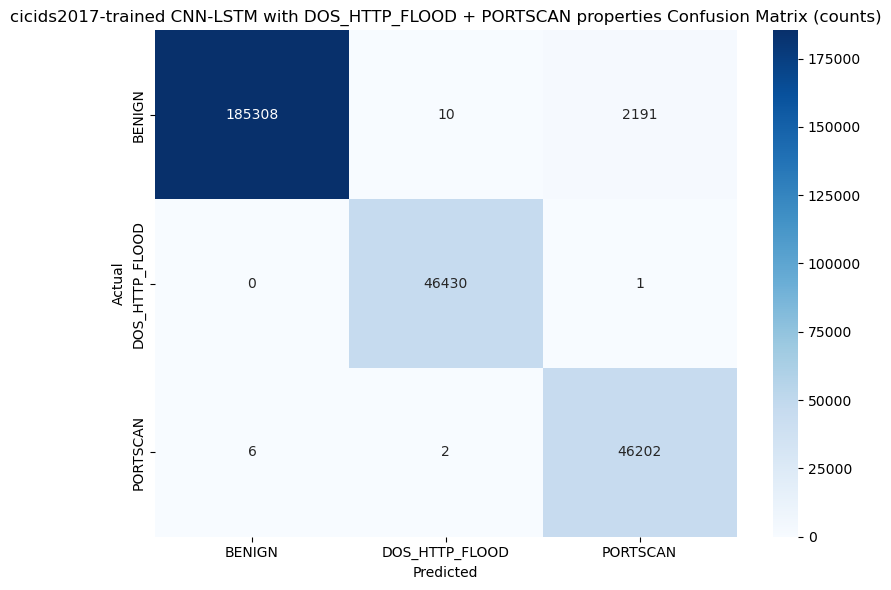


Saved model to: models/cnnlstm_property_cicids2017_multiclass.joblib


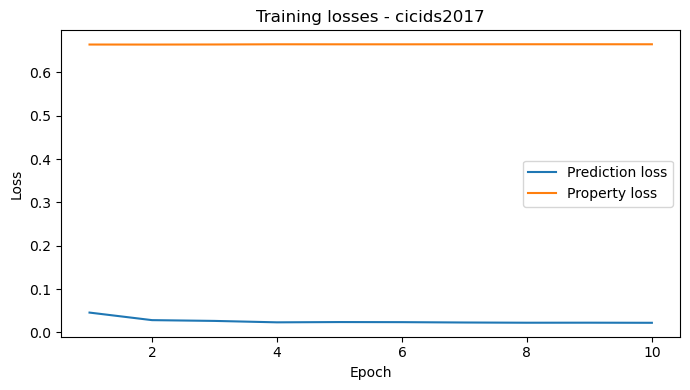


TRAINING ON: CICIOT2023
                    count          mean           std  min        25%  \
duration        2067377.0      9.230068  3.085147e+02  0.0   0.050125   
orig_bytes      2067377.0   5369.337175  1.401132e+06  0.0   0.000000   
resp_bytes      2067377.0  84037.799690  2.177130e+07  0.0   0.000000   
orig_pkts       2067377.0      5.171617  2.424629e+02  0.0   1.000000   
resp_pkts       2067377.0      3.882524  2.359968e+02  0.0   1.000000   
orig_pkt_rate   2067377.0  97426.300181  2.969856e+05  0.0   3.666370   
orig_byte_rate  2067377.0  22090.093035  6.818338e+06  0.0   0.000000   
pkt_asymmetry   2067377.0      1.135197  2.793073e+01  0.0   0.500000   
byte_asymmetry  2067377.0   2016.070547  1.395152e+06  0.0   0.000000   
time_elapsed    2067377.0   3056.605572  6.429705e+04  0.0   0.000000   
flood_rate      2067377.0  22090.093035  6.818338e+06  0.0   0.000000   
uniqDstPorts    2067377.0     53.824824  2.091653e+02  1.0   1.000000   
pktsPerPort     2067377.0 

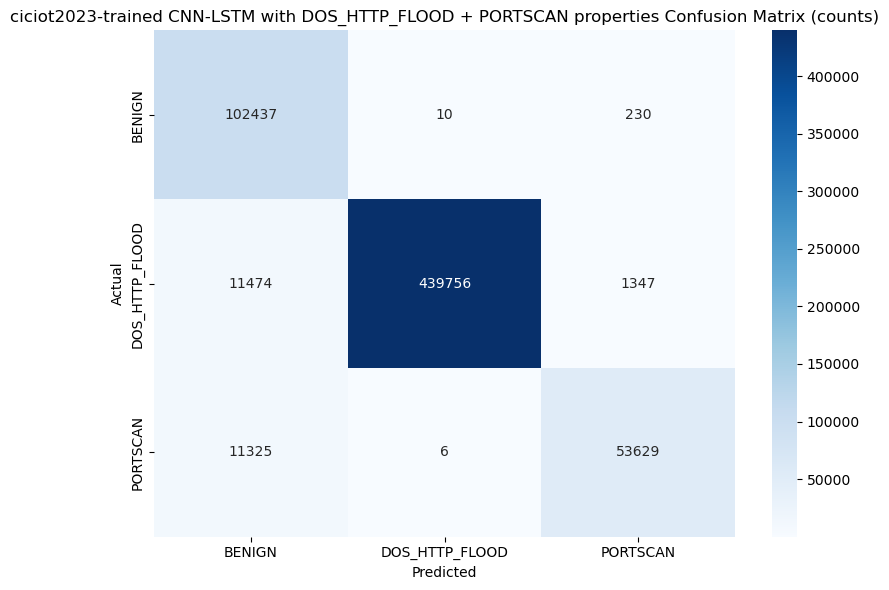


Saved model to: models/cnnlstm_property_ciciot2023_multiclass.joblib


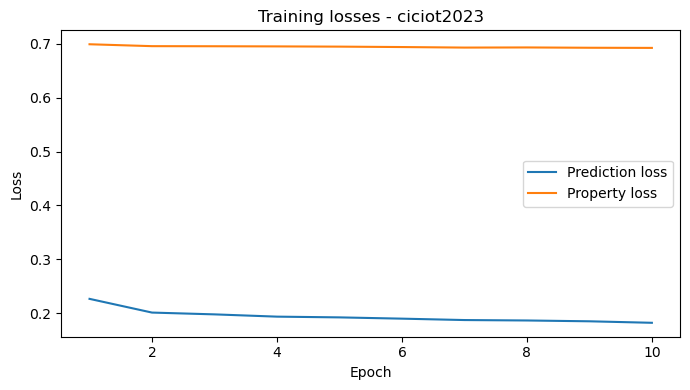

In [ ]:
for dataset_name, dataset_config in DATASETS.items():
    print("\n" + "=" * 70)
    print(f"TRAINING ON: {dataset_name.upper()}")
    print("=" * 70)

    df = dataset_config["data"].copy()
    df = add_portscan_attack_features(df, window_seconds=WINDOW_SECONDS)

    feature_cols = [c for c in FEATURES if c in df.columns]

    print("Shape:", df.shape)
    print(df["label"].value_counts())
    print("Features:", len(feature_cols))

    X = df[feature_cols].copy()
    y = df["label"].copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        stratify=y,
        random_state=42,
    )

    X_train_balanced, y_train_balanced = balance_dataset(X_train, y_train)

    label_encoder = LabelEncoder()
    y_train_enc = label_encoder.fit_transform(y_train_balanced)
    y_test_enc = label_encoder.transform(y_test)

    X_train_bal = X_train_balanced.copy()
    X_test_local = X_test.copy()

    categorical_cols = X_train_bal.select_dtypes(include=["object", "string", "bool"]).columns.tolist()
    ordinal_encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

    if len(categorical_cols) > 0:
        X_train_bal[categorical_cols] = ordinal_encoder.fit_transform(X_train_bal[categorical_cols])
        X_test_local[categorical_cols] = ordinal_encoder.transform(X_test_local[categorical_cols])

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_bal[feature_cols])
    X_test_scaled = scaler.transform(X_test_local[feature_cols])

    X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).unsqueeze(1)
    X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).unsqueeze(1)

    y_train_tensor = torch.tensor(y_train_enc, dtype=torch.long)
    y_test_tensor = torch.tensor(y_test_enc, dtype=torch.long)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=1024, shuffle=False)

    num_classes = len(label_encoder.classes_)
    model = CNNLSTM(n_features=len(feature_cols), num_classes=num_classes).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    properties = build_properties(
        device=device,
        scaler=scaler,
        feature_names=feature_cols,
        label_encoder=label_encoder,
    )

    x_batch, _ = next(iter(train_loader))
    x_batch = x_batch.to(device)
    prop_loss, prop_stats = properties.compute_loss(model, x_batch)

    print("Initial property loss:", prop_loss.item())
    print("Property stats:", prop_stats)

    history = []

    for epoch in range(NUM_EPOCHS):
        model.train()

        pred_losses = []
        prop_losses = []
        last_stats = {}

        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            logits = model(x_batch)
            pred_loss = criterion(logits, y_batch)

            prop_loss, prop_stats = properties.compute_loss(model, x_batch)
            
            # For the first few epochs, focus on prediction loss to allow the model to learn basic patterns. 
            # After that, start incorporating the property loss to guide the model towards satisfying the properties.
            if epoch < 3:
                loss = pred_loss
            else:
                loss = pred_loss + LAMBDA_PROP * prop_loss
            loss.backward()
            optimizer.step()

            pred_losses.append(pred_loss.item())
            prop_losses.append(prop_loss.item())
            last_stats = prop_stats

        avg_pred_loss = float(np.mean(pred_losses))
        avg_prop_loss = float(np.mean(prop_losses))

        history.append({
            "epoch": epoch + 1,
            "pred_loss": avg_pred_loss,
            "prop_loss": avg_prop_loss,
            **last_stats,
        })

        print(
            f"Epoch {epoch+1:02d} | "
            f"pred_loss={avg_pred_loss:.4f} | "
            f"prop_loss={avg_prop_loss:.4f} | "
            f"{', '.join(f'{k}={v:.4f}' for k, v in last_stats.items())}"
        )

    # evaluation
    model.eval()
    all_preds = []
    all_true = []

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)

            logits = model(x_batch)
            preds = torch.argmax(logits, dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_true.extend(y_batch.cpu().numpy())

    y_true_labels = label_encoder.inverse_transform(np.array(all_true))
    y_pred_labels = label_encoder.inverse_transform(np.array(all_preds))

    evaluate_model(
        y_true_labels,
        y_pred_labels,
        model_name=f"{dataset_name}-trained CNN-LSTM with DOS_HTTP_FLOOD + PORTSCAN properties",
    )

    os.makedirs("models", exist_ok=True)
    save_path = f"models/cnnlstm_property_{dataset_name}_multiclass.joblib"

    joblib.dump(
        {
            "model": model.cpu(),
            "ordinal_encoder": ordinal_encoder,
            "scaler": scaler,
            "label_encoder": label_encoder,
            "features": feature_cols,
            "categorical_cols": list(categorical_cols),
        },
        save_path,
    )

    print(f"\nSaved model to: {save_path}")

    history_df = pd.DataFrame(history)
    plt.figure(figsize=(7, 4))
    plt.plot(history_df["epoch"], history_df["pred_loss"], label="Prediction loss")
    plt.plot(history_df["epoch"], history_df["prop_loss"], label="Property loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Training losses - {dataset_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()